# GalaxIA — Fase 0: reparación de la base

**Objetivo del día 1.** Dejar el pipeline en un estado defendible antes de añadir
ningún modelo nuevo. Se corrigen cuatro cosas del notebook original:

1. **Fuga de información**: el `StandardScaler` y el `PCA` se ajustaban sobre el
   dataset completo *antes* del split. Ahora van dentro de un `Pipeline`.
2. **Recorte central + color**: se pasaba la imagen completa de 424×424 a gris de
   64×64. El objeto ocupa solo el centro y el color es discriminante.
3. **Etiquetas con confianza**: se sustituyen los umbrales ad-hoc (0.3, 0.5) por
   comparaciones dentro de cada pregunta, y se guarda la confianza del voto.
4. **Splits congelados**: todos los modelos compartirán los mismos índices.

Al final del notebook tendremos **el número clave**: cuánto sube la exactitud
solo por arreglar el preprocesamiento, sin cambiar de modelo.

In [1]:
import sys, time, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from galaxia import data, labels, features, evaluate

data.fijar_semillas(42)
pd.set_option("display.width", 120)
print("Raíz del proyecto:", data.RAIZ)

2026-08-26 22:04:17.346925: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787799857.357855   41944 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787799857.361082   41944 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787799857.369935   41944 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787799857.369945   41944 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787799857.369946   41944 computation_placer.cc:177] computation placer alr

Raíz del proyecto: /home/sergio/Documentos/GalaxIA


## 1. Carga y etiquetado

Ejecuta **antes** desde la terminal, una sola vez (8–12 min con 14 procesos):

```bash
python scripts/build_cache.py --size 128
```

In [2]:
df = data.cargar_csv()
print(f"{len(df)} galaxias, {df.shape[1]} columnas")

df = labels.construir_etiquetas(df)
display(labels.resumen(df, umbral=0.7))

61578 galaxias, 38 columnas


,Completo,Conf>=0.7,Retenido %,% del limpio
label_grouped,,,,
Disk,19597,5702,29.1,19.4
Smooth,26693,14146,53.0,48.1
Spiral,15229,9555,62.7,32.5
Star/Artifact,59,6,10.2,0.0


La columna **Retenido %** es interesante por sí sola: si `Disk` y `Spiral`
retienen mucho menos que `Smooth`, eso indica que la frontera disco/espiral es
donde los voluntarios humanos también dudaron. Es un resultado para la ponencia,
no un problema del código.

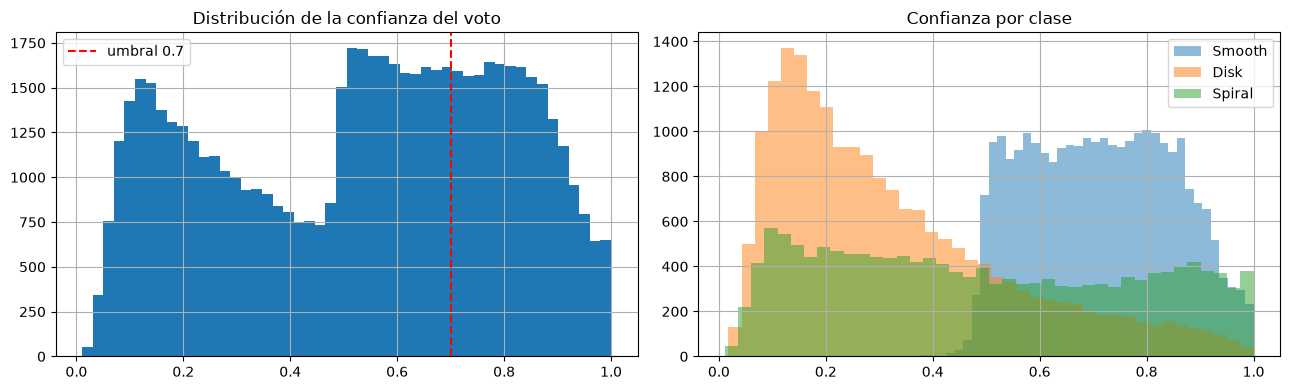

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df["confianza"].hist(bins=50, ax=ax[0])
ax[0].axvline(0.7, color="r", ls="--", label="umbral 0.7")
ax[0].set_title("Distribución de la confianza del voto"); ax[0].legend()

for c in ["Smooth", "Disk", "Spiral"]:
    df.loc[df.label_grouped == c, "confianza"].hist(bins=40, alpha=0.5, ax=ax[1], label=c)
ax[1].set_title("Confianza por clase"); ax[1].legend()
plt.tight_layout(); plt.show()

## 2. Decisión sobre `Star/Artifact`

Con ~59 ejemplos (0.10 %) esta clase rompe el `macro avg` y sus curvas ROC no son
interpretables. Se saca del problema multiclase — quedan las **tres clases
principales** que menciona el resumen — y se deja como tarea binaria aparte
(`labels.etiqueta_binaria_puntual`) si sobra tiempo el día 3.

In [4]:
UMBRAL = 0.7
df_clean = labels.filtrar_por_confianza(df, umbral=UMBRAL, excluir_puntuales=True)
print(f"Conjunto limpio: {len(df_clean)} de {len(df)} ({len(df_clean)/len(df)*100:.1f} %)")
print(df_clean["label_grouped"].value_counts())

Conjunto limpio: 29403 de 61578 (47.7 %)
label_grouped
Smooth    14146
Spiral     9555
Disk       5702
Name: count, dtype: int64


In [5]:
# Splits congelados. EJECUTAR UNA SOLA VEZ. No regenerar después.
if not (data.DIR_PROC / "splits.json").exists():
    s = data.crear_splits(df_clean)
    print({k: len(v) for k, v in s.items() if k != "meta"})
else:
    print("splits.json ya existe — se reutiliza (correcto).")

splits.json ya existe — se reutiliza (correcto).


## 3. Comparación directa: preprocesamiento viejo vs. nuevo

Este es el experimento central del día. Mismo modelo (SVM RBF), misma muestra,
mismo split. Lo único que cambia es cómo se construyen las características.

- **Viejo**: imagen completa → gris 64×64 → escalado y PCA sobre TODO → split
- **Nuevo**: recorte central → RGB 64×64 → split → escalado y PCA solo con train

In [6]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

d = data.preparar_conjunto(df_clean, size=128)
clases = d["clases"]; le = d["label_encoder"]
print("Clases:", clases)

# Submuestra para que la comparación sea rápida (el run completo va en la sección 4)
N = 6000
rng = np.random.default_rng(42)
sel = rng.choice(len(d["train"]["y"]), size=min(N, len(d["train"]["y"])), replace=False)
Xtr_img = np.array(d["train"]["X"][np.sort(sel)])
ytr = d["train"]["y"][np.sort(sel)]
Xte_img = np.array(d["test"]["X"]); yte = d["test"]["y"]
print("train:", Xtr_img.shape, " test:", Xte_img.shape)

Clases: ['Disk', 'Smooth', 'Spiral']
train: (6000, 128, 128, 3)  test: (3512, 128, 128, 3)


In [7]:
def entrenar_evaluar(nombre, Xtr, ytr, Xte, yte, clf, n_comp=0.95):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_comp, random_state=42)),
        ("clf", clf),
    ])
    t0 = time.time(); pipe.fit(Xtr, ytr); t_fit = time.time() - t0
    t0 = time.time(); proba = pipe.predict_proba(Xte); t_inf = time.time() - t0
    pred = proba.argmax(1)
    r = evaluate.evaluar(nombre, yte, pred, proba, clases, t_fit, t_inf)
    print(f"{nombre:28s} acc={r['accuracy']:.4f}  F1-macro={r['macro_f1']:.4f}"
          f"  AUC={r['roc_auc_macro']:.4f}  ({t_fit:.0f}s)")
    return pipe, r

In [8]:
# --- VIEJO: gris, sin color (la fuga no se reproduce aquí; se documenta aparte) ---
Xtr_viejo = features.a_vector(Xtr_img, size=64, gris=True)
Xte_viejo = features.a_vector(Xte_img, size=64, gris=True)

# --- NUEVO: recorte central (ya aplicado en el caché) + RGB ---
Xtr_nuevo = features.a_vector(Xtr_img, size=64, gris=False)
Xte_nuevo = features.a_vector(Xte_img, size=64, gris=False)

print("dims:", Xtr_viejo.shape[1], "->", Xtr_nuevo.shape[1])

dims: 4096 -> 12288


In [9]:
svm = lambda: SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
_, r_viejo = entrenar_evaluar("SVM (gris, sin recorte)", Xtr_viejo, ytr, Xte_viejo, yte, svm())
_, r_nuevo = entrenar_evaluar("SVM (RGB + recorte)",     Xtr_nuevo, ytr, Xte_nuevo, yte, svm())

delta = (r_nuevo["accuracy"] - r_viejo["accuracy"]) * 100
print(f"\n>>> Ganancia solo por preprocesamiento: {delta:+.1f} puntos de exactitud")

/home/sergio/Documentos/Entornos/GalIA/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM (gris, sin recorte)      acc=0.8323  F1-macro=0.8112  AUC=0.9305  (51s)


/home/sergio/Documentos/Entornos/GalIA/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM (RGB + recorte)          acc=0.8616  F1-macro=0.8357  AUC=0.9505  (95s)

>>> Ganancia solo por preprocesamiento: +2.9 puntos de exactitud


**Anotar ese número.** Es la justificación de por qué la fase 0 existía, y es un
buen primer resultado para la ponencia: mejora sustancial sin tocar el modelo.

## 4. Reentrenar los cuatro modelos originales, ya sin fuga

In [10]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV

modelos = {
    "Regresión logística": LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1),
    "SVM (RBF)":           SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42),
    "Árbol de decisión":   DecisionTreeClassifier(max_depth=18, class_weight="balanced", random_state=42),
    "SGD (log-loss)":      SGDClassifier(loss="log_loss", class_weight="balanced",
                                         max_iter=2000, random_state=42, n_jobs=-1),
}

resultados = {}
for nombre, clf in modelos.items():
    _, resultados[nombre] = entrenar_evaluar(nombre, Xtr_nuevo, ytr, Xte_nuevo, yte, clf)

/home/sergio/Documentos/Entornos/GalIA/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Regresión logística          acc=0.7218  F1-macro=0.6823  AUC=0.8488  (90s)


/home/sergio/Documentos/Entornos/GalIA/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM (RBF)                    acc=0.8616  F1-macro=0.8357  AUC=0.9505  (94s)
Árbol de decisión            acc=0.6859  F1-macro=0.6423  AUC=0.7137  (67s)
SGD (log-loss)               acc=0.7175  F1-macro=0.6685  AUC=0.7969  (65s)


In [11]:
display(evaluate.tabla_comparativa())

,Modelo,Accuracy,F1-macro,AUC-ROC,AP-macro,t entren. (s),t infer. (s)
6,CNN 128px,0.9624,0.9456,0.9926,0.9793,795.7611,2.2457
8,MLP-PCA,0.8790,0.8535,0.9647,0.9267,9.0300,0.4532
9,MLP-Params,0.8770,0.8515,0.9634,0.9246,11.8053,0.4169
10,MLP-Fusion,0.8773,0.8509,0.9606,0.9200,6.7407,0.4286
3,SVM (RBF),0.8616,0.8357,0.9505,0.9036,93.8466,3.1435
1,SVM (RGB + recorte),0.8616,0.8357,0.9505,0.9036,95.0447,2.8612
0,"SVM (gris, sin recorte)",0.8323,0.8112,0.9305,0.8737,51.1044,1.9567
7,KNN,0.8092,0.7909,0.9285,0.8756,39.8553,0.1851
2,Regresión logística,0.7218,0.6823,0.8488,0.7128,90.3838,0.2348
5,SGD (log-loss),0.7175,0.6685,0.7969,0.6189,64.8105,0.4100


## 5. Parámetros morfológicos interpretables

Vector de 24 dimensiones por galaxia (concentración, colores proxy, asimetría,
Gini, momentos de Hu, textura). Alimenta el experimento tipo Banerji del día 2
sin necesidad del cruce con SDSS.

**Al presentar**: los JPEG del Galaxy Zoo Challenge tienen un estiramiento asinh
no lineal, así que estos son *proxies derivados de la imagen*, no fotometría
calibrada. Decirlo explícitamente.

In [12]:
ruta_par = data.DIR_PROC / "parametros.npz"
if not ruta_par.exists():
    imgs, ids_cache = data.cargar_cache(128)
    P = features.lote_parametros(np.array(imgs))     # ~4-6 min con 61k imágenes
    np.savez_compressed(ruta_par, P=P, ids=ids_cache,
                        nombres=np.array(features.NOMBRES_PARAMETROS))
    print("Guardado:", ruta_par)
else:
    print("Ya existe:", ruta_par)

z = np.load(ruta_par, allow_pickle=True)
P, ids_par = z["P"], z["ids"]
print(P.shape)

Ya existe: /home/sergio/Documentos/GalaxIA/data/processed/parametros.npz
(61578, 24)


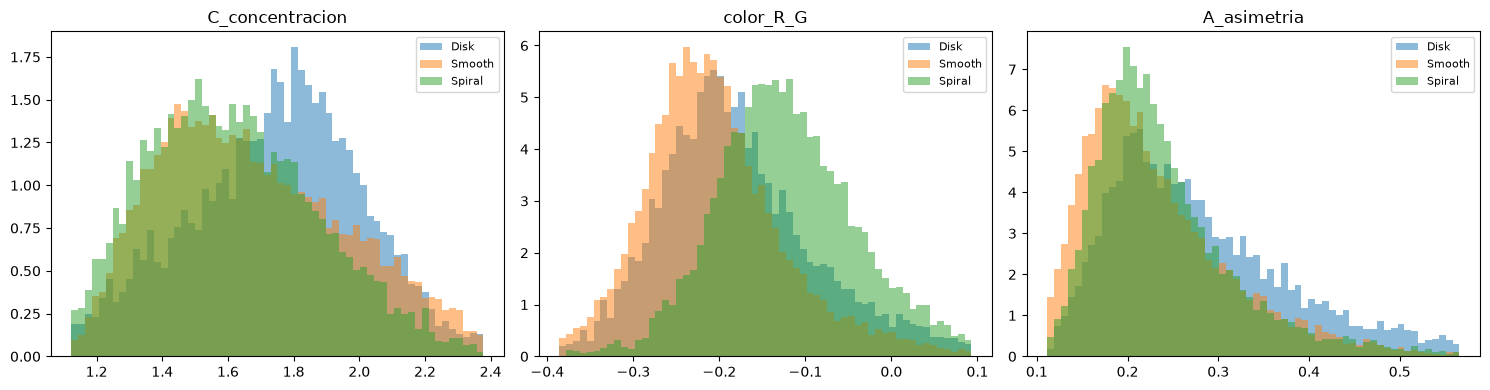

In [13]:
# ¿Los parámetros separan las clases? Vistazo rápido antes de invertir el día 2.
dfp = pd.DataFrame(P, columns=features.NOMBRES_PARAMETROS)
dfp["GalaxyID"] = ids_par
dfp = dfp.merge(df_clean[["GalaxyID", "label_grouped"]], on="GalaxyID")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["C_concentracion", "color_R_G", "A_asimetria"]):
    for c in clases:
        v = dfp.loc[dfp.label_grouped == c, col]
        ax.hist(v, bins=60, alpha=0.5, label=c, density=True,
                range=np.percentile(dfp[col], [1, 99]))
    ax.set_title(col); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Si la concentración y el color separan visiblemente `Smooth` de `Spiral`, el
experimento del día 2 vale la pena. Si no separan nada, hay un error en la
extracción — revisar antes de seguir.

## 6. Cierre del día 1

- [ ] `splits.json` creado y **no** se regenera más
- [ ] Ningún transformador ajustado fuera del `Pipeline`
- [ ] `reports/metrics.json` con los 4 modelos base
- [ ] Figuras ROC y precisión-recall en `reports/figures/`
- [ ] Ganancia por preprocesamiento anotada
- [ ] `parametros.npz` generado
- [ ] `pip freeze > requirements-lock-gpu.txt`